<a href="https://colab.research.google.com/github/kiobov/Analytics/blob/master/RevenueandCustomerInsights/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis

In [1]:
#imports
#!pip install duckdb -q
import duckdb, pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

#!pip install plotly -q

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

#!pip install scikit-learn imbalanced-learn -q

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

#!pip install prophet -q

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from prophet.plot import seasonality_plot_df



In [2]:
# mount data
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#read data
oct = pd.read_csv("/content/drive/MyDrive/ecommerce-events/2019-Oct.csv")
nov = pd.read_csv("/content/drive/MyDrive/ecommerce-events/2019-Nov.csv")
dec = pd.read_csv("/content/drive/MyDrive/ecommerce-events/2019-Dec.csv")
jan = pd.read_csv("/content/drive/MyDrive/ecommerce-events/2020-Jan.csv")
feb = pd.read_csv("/content/drive/MyDrive/ecommerce-events/2020-Feb.csv")


#add a month column to each
oct['month'] = 'Oct-2019'
nov['month'] = 'Nov-2019'
dec['month'] = 'Dec-2019'
jan['month'] = 'Jan-2020'
feb['month'] = 'Feb-2020'

#combine data frame
df = pd.concat([oct, nov, dec, jan,feb], ignore_index=True)

print(f"Total rows:  {len(df): }")
print(f"Date range: {df['event_time'].min()} to {df['event_time'].max()}")
df.head(3)

Total rows:   20692840
Date range: 2019-10-01 00:00:00 UTC to 2020-02-29 23:59:59 UTC


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,Oct-2019
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,Oct-2019
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,Oct-2019


## First look at our question

Stake holder question : Our sales feel inconsistent and we're spending money on customers who don't come back what is going on and what should we do about it?

What we are looking for and @
1. Month over month trends
- did revenue grow or shrink jan-feb?
- did conversion rate improve
- which month had the worst cart abandonment
2. Cohort thinking - following users overtime
- of the users who bought in dec , how many came back in jan
- how much did returning users spend vs new users
3. Product trend
- which products grew fastest month over month
- which brands are declining

4. Basket analysis - session level behaviour
- how many products does a user view before buying
- how long does it take from first vies to purchase
5. customer segmentation
- score every customer on recency, loyal, at risk, lost
- segment into champion, loyal, at risk, lost


In [4]:
# Question 1
#month over month trends- revenue,orders and conversion rate

duckdb.query("""
        WITH monthly_events AS (
          SELECT
              month,
              CASE month
                WHEN 'Oct-2019' THEN 1
                WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3
                WHEN 'Jan-2020' THEN 4
                WHEN 'Feb-2020' THEN 5
            END AS month_order,
              COUNT(CASE WHEN event_type = 'view' THEN 1 END ) AS views,
              COUNT(CASE WHEN event_type = 'cart' THEN 1 END ) AS cart_adds,
              COUNT(CASE WHEN event_type = 'purchase' THEN 1 END ) AS purchases,
              COUNT(DISTINCT CASE WHEN event_type = 'Purchase' THEN user_id END ) AS unique_buyers,
              ROUND(SUM(CASE WHEN event_type = 'purchase' THEN price END), 2) AS revenue
          FROM df
          GROUP BY month
        )
        SELECT
            month,
            views,
            cart_adds,
            purchases,
            unique_buyers,
            revenue,
            ROUND(purchases*100.0/NULLIF(cart_adds, 0), 1) AS cart_conversion_pct,
            ROUND(revenue/ NULLIF(unique_buyers,0), 2) AS revenue_per_buyer
        FROM monthly_events
        ORDER BY month_order

""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,views,cart_adds,purchases,unique_buyers,revenue,cart_conversion_pct,revenue_per_buyer
0,Oct-2019,1862164,1232385,245624,0,1211538.43,19.9,NaN
1,Nov-2019,2076132,1311807,322417,0,1531016.90,24.6,NaN
2,Dec-2019,1728331,927124,213176,0,1077624.85,23.0,NaN
3,Jan-2020,2037608,1148323,263797,0,1321535.48,23.0,NaN
4,Feb-2020,1953586,1148694,241993,0,1206289.21,21.1,NaN


In [5]:
#Question 1: month over month growth rates using lag()
duckdb.query("""
      WITH monthly AS (
          SELECT
              month,
              ROUND(SUM(CASE WHEN event_type = 'purchase' THEN price END), 2) AS revenue,
              COUNT(CASE WHEN event_type = 'purchase' THEN 1 END ) AS purchases,
                  CASE month
                        WHEN 'Oct-2019' THEN 1
                        WHEN 'Nov-2019' THEN 2
                        WHEN 'Dec-2019' THEN 3
                        WHEN 'Jan-2020' THEN 4
                        WHEN 'Feb-2020' THEN 5
                  END
          FROM df
          GROUP BY month

      ),
      with_lag AS (
        SELECT
            month,
            revenue,
            purchases,
            LAG(revenue) OVER (ORDER BY month) AS prev_revenue,
            LAG(purchases) OVER (ORDER BY month) AS prev_purchases
        FROM monthly
      )
      SELECT
          month,
          revenue,
          purchases,
          ROUND((revenue-prev_revenue)*100.0/NULLIF(prev_revenue,0), 1) AS revenue_growth_pct,
          ROUND((purchases-prev_purchases)*100.0/ NULLIF(prev_purchases,0), 1) AS purchase_growth_pct
      FROM with_lag
      ORDER BY
          CASE month
                WHEN 'Oct-2019' THEN 1
                WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3
                WHEN 'Jan-2020' THEN 4
                WHEN 'Feb-2020' THEN 5
          END

      """).df()

,month,revenue,purchases,revenue_growth_pct,purchase_growth_pct
0,Oct-2019,1211538.43,245624,-20.9,-23.8
1,Nov-2019,1531016.90,322417,15.9,22.2
2,Dec-2019,1077624.85,213176,NaN,NaN
3,Jan-2020,1321535.48,263797,9.6,9.0
4,Feb-2020,1206289.21,241993,11.9,13.5


#### Visual Insights
November was peak month likely driven by black friday and pre holiday shopping. December suprisingly dropped 30% which is counterintuitive for the store . january recovered strongly due to new year purchases. feb dipped slightly possibly shorter month effect

In [6]:
#lets see why dec declined
duckdb.query("""
        WITH monthly AS (
              SELECT
                  month,
                  CASE month
                        WHEN 'Oct-2019' THEN 1
                        WHEN 'Nov-2019' THEN 2
                        WHEN 'Dec-2019' THEN 3
                        WHEN 'Jan-2020' THEN 4
                        WHEN 'Feb-2020' THEN 5
                  END as month_order,
                  COUNT(DISTINCT user_id) AS total_users,
                  COUNT(DISTINCT CASE WHEN event_type='purchase' THEN user_id END) AS buyers,
                  COUNT(CASE WHEN event_type='purchase' THEN 1 END) as purchases,
                  ROUND(AVG(CASE WHEN event_type ='purchase' THEN price END ), 2)  AS avg_order_value,
                  ROUND(SUM(CASE WHEN event_type='purchase' THEN price END ), 2) AS revenue,
                  ROUND(COUNT(CASE WHEN event_type='purchase' THEN 1 END ) * 100.0/NULLIF(COUNT(CASE WHEN event_type='cart' THEN 1 END), 0), 1) AS cart_conversion_pct

              FROM df
              GROUP BY month
)
            SELECT
                month,
                total_users,
                buyers,
                ROUND(buyers *100.0/NULLIF(total_users,0), 1) AS user_to_buyer_pct,
                avg_order_value,
                cart_conversion_pct,
                revenue
            FROM monthly
            ORDER BY month_order



""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,total_users,buyers,user_to_buyer_pct,avg_order_value,cart_conversion_pct,revenue
0,Oct-2019,399664,25762,6.4,4.93,19.9,1211538.43
1,Nov-2019,368232,31524,8.6,4.75,24.6,1531016.90
2,Dec-2019,370154,25613,6.9,5.06,23.0,1077624.85
3,Jan-2020,410073,28220,6.9,5.01,23.0,1321535.48
4,Feb-2020,391055,25759,6.6,4.98,21.1,1206289.21


### Visual Insights
December revenue drop wasnt a pricing or checkout problem. The same number of people visited but 19% fewer decided to buy. This suggests nov black friday and preholiday promotions pulled purchases forward hence people buying in november instead of november

Loyalty however is worrying 6-8% of the visitors become buyers - now promotions bring buyers in but dont retain them.The business is on a treadmill, spending to acquire customers who don't return

In [7]:
#Question 2 cohort analysis - retention cohort
# of which customers who bought in oct, how many
#cameback in nov ?dec? did we retain any at all?

#segment each users 1st purchase month

duckdb.query("""
        WITH first_purchase AS (
          SELECT
              user_id,
              MIN(CASE month
                  WHEN 'Oct-2019' THEN 1
                  WHEN 'Nov-2019' THEN 2
                  WHEN 'Dec-2019' THEN 3
                  WHEN 'Jan-2020' THEN 4
                  WHEN 'Feb-2020' THEN 5
                END ) AS cohort_month_num,
                MIN(month) AS cohort_month
          FROM df
          WHERE event_type='purchase'
          GROUP BY user_id),
        purchases AS (
            SELECT
                user_id,
                CASE month
                        WHEN 'Oct-2019' THEN 1
                        WHEN 'Nov-2019' THEN 2
                        WHEN 'Dec-2019' THEN 3
                        WHEN 'Jan-2020' THEN 4
                        WHEN 'Feb-2020' THEN 5
                END AS purchase_month_num
            FROM df
            WHERE event_type = 'purchase'
        )
        SELECT
          f.cohort_month,
          f.cohort_month_num,
          p.purchase_month_num - f.cohort_month_num AS months_since_first,
          COUNT(DISTINCT P.user_id) AS users
        FROM first_purchase f
        JOIN purchases p ON f.user_id = p.user_id
        GROUP BY f.cohort_month, f.cohort_month_num, months_since_first
        ORDER BY f.cohort_month_num, months_since_first

""").df()


,cohort_month,cohort_month_num,months_since_first,users
0,Nov-2019,1,0,1864
1,Oct-2019,1,0,17834
2,Feb-2020,1,0,1440
3,Dec-2019,1,0,3293
4,Jan-2020,1,0,1331
5,Feb-2020,1,1,679
6,Jan-2020,1,1,499
7,Dec-2019,1,1,1721
8,Nov-2019,1,1,1864
9,Dec-2019,1,2,3293


In [8]:
# Fixed cohort analysis - using month_num throughout to avoid text matching issues
duckdb.query("""
    WITH purchases_clean AS (
        SELECT
            user_id,
            CASE month
                WHEN 'Oct-2019' THEN 1
                WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3
                WHEN 'Jan-2020' THEN 4
                WHEN 'Feb-2020' THEN 5
            END AS month_num,
            month
        FROM df
        WHERE event_type = 'purchase'
    ),
    first_purchase AS (
        SELECT
            user_id,
            MIN(month_num) AS cohort_num
        FROM purchases_clean
        GROUP BY user_id
    ),
    cohort_activity AS (
        SELECT
            f.cohort_num,
            p.month_num,
            p.month_num - f.cohort_num      AS months_since_first,
            COUNT(DISTINCT p.user_id)        AS active_users
        FROM first_purchase f
        JOIN purchases_clean p ON f.user_id = p.user_id
        GROUP BY f.cohort_num, p.month_num, months_since_first
    ),
    cohort_sizes AS (
        SELECT cohort_num, active_users AS cohort_size
        FROM cohort_activity
        WHERE months_since_first = 0
    )
    SELECT
        CASE c.cohort_num
            WHEN 1 THEN 'Oct-2019'
            WHEN 2 THEN 'Nov-2019'
            WHEN 3 THEN 'Dec-2019'
            WHEN 4 THEN 'Jan-2020'
            WHEN 5 THEN 'Feb-2020'
        END                                                     AS cohort,
        c.months_since_first,
        c.active_users,
        s.cohort_size,
        ROUND(c.active_users * 100.0 / s.cohort_size, 1)       AS retention_pct
    FROM cohort_activity c
    JOIN cohort_sizes s ON c.cohort_num = s.cohort_num
    ORDER BY c.cohort_num, c.months_since_first
""").df()

,cohort,months_since_first,active_users,cohort_size,retention_pct
0,Oct-2019,0,25762,25762,100.0
1,Oct-2019,1,4763,25762,18.5
2,Oct-2019,2,3293,25762,12.8
3,Oct-2019,3,3399,25762,13.2
4,Oct-2019,4,2692,25762,10.4
5,Nov-2019,0,26761,26761,100.0
6,Nov-2019,1,2618,26761,9.8
7,Nov-2019,2,2716,26761,10.1
8,Nov-2019,3,2119,26761,7.9
9,Dec-2019,0,19702,19702,100.0


## Visual Insights
After just one month , the business loses 80-90% of new customers regardless of which they joined . There is a loyalty problem the sypre is essentially refilling a leaking bucket every month. Although in months lick october where customers found us organically we are anle to retaon them

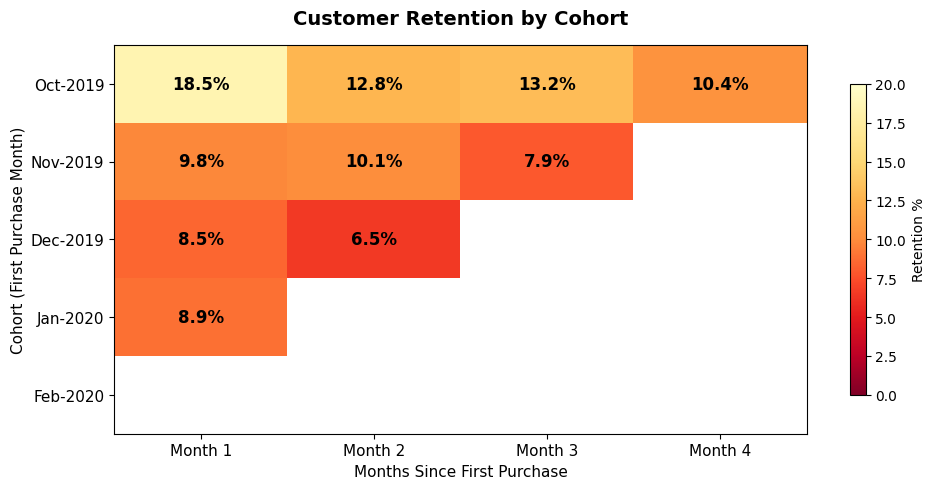

In [9]:
# Build the pivot table for heatmap
cohort_data = {
    'Oct-2019': [18.5, 12.8, 13.2, 10.4],
    'Nov-2019': [9.8, 10.1,  7.9,  None],
    'Dec-2019': [8.5,  6.5, None,  None],
    'Jan-2020': [8.9, None,  None,  None],
    'Feb-2020': [None, None,  None,  None],
}

cohort_df = pd.DataFrame(
    cohort_data,
    index=['Month 1','Month 2','Month 3','Month 4']
).T

fig, ax = plt.subplots(figsize=(10, 5))

# Mask a none values
data_array = cohort_df.values.astype(float)
display_data = np.where(np.isnan(data_array), np.nan, data_array)

im = ax.imshow(
    np.where(display_data == 100, np.nan, display_data),
    cmap='YlOrRd_r', aspect='auto', vmin=0, vmax=20
)
for i in range(len(cohort_df.index)):
    for j in range(len(cohort_df.columns)):
        val = data_array[i, j]
        if not np.isnan(val):
            color = 'white' if val < 10 else 'black'
            bg = '#2ecc71' if val == 100.0 else None
            if bg:
                ax.add_patch(plt.Rectangle(
                    (j-0.5, i-0.5), 1, 1,
                    color=bg, zorder=1
                ))
            ax.text(j, i, f'{val}%', ha='center', va='center',
                   fontsize=12, fontweight='bold',
                   color='white' if val == 100 else 'black',
                   zorder=2)

ax.set_xticks(range(len(cohort_df.columns)))
ax.set_xticklabels(cohort_df.columns, fontsize=11)
ax.set_yticks(range(len(cohort_df.index)))
ax.set_yticklabels(cohort_df.index, fontsize=11)
ax.set_title('Customer Retention by Cohort', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)

plt.colorbar(im, ax=ax, label='Retention %', shrink=0.8)
plt.tight_layout()
plt.show()


In [10]:
#Question 3 Recency, Frequency, monetary scoring

duckdb.query("""
        WITH user_stats AS (
              SELECT
                  user_id,
                  COUNT(*) as frequency,
                  ROUND(SUM(price) ,2) AS monetary,
                  MAX(CAST(event_time AS timestamp)) AS last_purchase,
                  DATE_DIFF('day', MAX(CAST(event_time AS TIMESTAMP)),
                  CAST('2020-02-29' AS TIMESTAMP)) AS recency_days

              FROM df
              WHERE event_type = 'purchase'
              GROUP BY user_id

        ),
        rfm_scores AS (
            SELECT
                user_id,
                recency_days,
                frequency,
                monetary,
                NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
                NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
                NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
            FROM user_stats
        )
        SELECT
            user_id,
            recency_days,
            frequency,
            monetary,
            r_score,
            f_score,
            m_score,
            r_score+ f_score + m_score AS rfm_total,
            CASE
                WHEN r_score = 4 AND f_score >=3 THEN 'Champion'
                WHEN r_score >= 3 AND f_score >=2 THEN 'Loyal'
                WHEN r_score >=3 AND f_score =1 THEN 'Promising'
                WHEN r_score = 2  AND f_score >=3 THEN 'At risk'
                WHEN r_score = 1 AND f_score  >=3 THEN 'Lost'
                ELSE 'Other'
                END AS segment

        FROM rfm_scores
        ORDER BY rfm_total DESC
        LIMIT 20


""").df()

,user_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_total,segment
0,593423941,8,15,61.53,4,4,4,12,Champion
1,472285023,4,14,61.65,4,4,4,12,Champion
2,544539678,6,24,61.57,4,4,4,12,Champion
3,541244824,20,16,61.75,4,4,4,12,Champion
4,602994976,19,21,61.71,4,4,4,12,Champion
5,596128980,8,13,61.58,4,4,4,12,Champion
6,613271434,17,23,61.63,4,4,4,12,Champion
7,603663759,18,21,61.78,4,4,4,12,Champion
8,234361852,20,26,61.75,4,4,4,12,Champion
9,483549856,4,27,61.67,4,4,4,12,Champion


In [11]:
#segments breakdown
duckdb.query("""
      WITH user_stats AS (
            SELECT
                user_id,
                COUNT(*) AS frequency,
                ROUND(SUM(price), 2) AS monetary,
                DATE_DIFF('day',
                MAX(CAST(event_time AS TIMESTAMP)),
                CAST('2020-02-29' AS TIMESTAMP)) AS recency_days
            FROM df
            WHERE event_type ='purchase'
            GROUP BY user_id

      ),
      rfm_scores AS (
        SELECT
            user_id,
            recency_days,
            frequency,
            monetary,
            NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
            NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
        FROM user_stats

      ),
      rfm_segments AS (
        SELECT
            user_id,
            recency_days,
            frequency,
            monetary,
            r_score,
            f_score,
            m_score,
            CASE
              WHEN r_score = 4 AND f_score >=3 THEN 'Champion'
                WHEN r_score >= 3 AND f_score >=2 THEN 'Loyal'
                WHEN r_score >=3 AND f_score =1 THEN 'Promising'
                WHEN r_score = 2  AND f_score >=3 THEN 'At risk'
                WHEN r_score = 1 AND f_score  >=3 THEN 'Lost'
                ELSE 'Other'
                END AS segment

        FROM rfm_scores
      )
      SELECT
          segment,
          COUNT(*) AS num_customers,
          ROUND(COUNT(*) * 100.0/ SUM(COUNT(*)) OVER (), 1) AS pct_of_customers,
          ROUND(AVG(frequency), 1) AS avg_purchases,
          ROUND(AVG(monetary), 2) AS avg_spent,
          ROUND(AVG(recency_days), 0) AS avg_days_since_purchase,
          ROUND(SUM(monetary), 2) AS total_revenue_contributed
    FROM rfm_segments
    GROUP BY segment
    ORDER BY total_revenue_contributed DESC

""").df()

,segment,num_customers,pct_of_customers,avg_purchases,avg_spent,avg_days_since_purchase,total_revenue_contributed
0,Champion,15178,13.7,27.8,125.85,14.0,1910100.82
1,Loyal,29439,26.6,11.6,56.64,39.0,1667322.18
2,At risk,14446,13.1,16.5,70.05,89.0,1011956.58
3,Lost,12253,11.1,15.2,64.31,126.0,787952.92
4,Other,28561,25.8,2.9,25.28,110.0,722087.17
5,Promising,10641,9.6,1.5,23.36,34.0,248585.20


## Visual Insights
15% of our champion customers generate 31% of all the revenues. The top 2 segments champions+Loyal are 40% of the customer base but drive 57% revenue

In [12]:
#how do we treat each segment group
#according to their behaviour
duckdb.query("""
      WITH user_stats AS (
        SELECT
                user_id,
                COUNT(*) AS frequency,
                ROUND(SUM(price), 2) AS monetary,
                DATE_DIFF('day',
                MAX(CAST(event_time AS TIMESTAMP)),
                CAST('2020-02-29' AS TIMESTAMP)) AS recency_days
            FROM df
            WHERE event_type ='purchase'
            GROUP BY user_id
      ),
        rfm_scores AS (
        SELECT
            user_id,
            recency_days,
            frequency,
            monetary,
            NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
            NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
        FROM user_stats
      )
      SELECT

            CASE
              WHEN r_score = 4 AND f_score >=3 THEN 'Champion'
                WHEN r_score >= 3 AND f_score >=2 THEN 'Loyal'
                WHEN r_score >=3 AND f_score =1 THEN 'Promising'
                WHEN r_score = 2  AND f_score >=3 THEN 'At risk'
                WHEN r_score = 1 AND f_score  >=3 THEN 'Lost'
                ELSE 'Other'
                END AS segment,
                COUNT(DISTINCT user_id) AS users,
                ROUND(AVG(frequency), 1) AS avg_orders,
                ROUND(AVG(monetary), 2) AS avg_total_spent,
                ROUND(MIN(monetary), 2) AS min_spent,
                ROUND(MAX(monetary), 2) AS max_spent,
                ROUND(AVG(recency_days), 2) AS avg_recency_days
    FROM rfm_scores
    GROUP BY segment
    ORDER BY avg_total_spent DESC



""").df()


,segment,users,avg_orders,avg_total_spent,min_spent,max_spent,avg_recency_days
0,Champion,16545,26.0,118.53,-10.52,3785.03,14.31
1,At risk,12832,17.9,74.82,-1.03,2715.87,88.70
2,Lost,11394,15.8,66.39,-2.73,1109.70,127.32
3,Loyal,23468,13.6,64.20,-8.94,1843.32,41.41
4,Other,31034,3.2,25.92,-7.20,535.77,108.98
5,Promising,15245,2.0,23.57,-2.38,599.62,34.51


## Visual Insight
 Winning back At risk + LOst that is =  20% of At Risk customers would recover $191,000 in revenue. A re-engagement campaign costing less than that has a positive ROI.

In [13]:
#lets first check the negative min-spents

duckdb.query("""
      SELECT
          event_type,
          COUNT(*) AS total_records,
          COUNT(CASE WHEN price <0 THEN 1 END ) AS negative_prices,
          COUNT(CASE WHEN price =0 THEN 1 END ) AS zero_prices,
          ROUND(MIN(price), 2 ) AS min_price,
          ROUND(MAX(price), 2) AS max_price
      FROM df
      WHERE event_type = 'purchase'
      GROUP BY event_type
""").df()

,event_type,total_records,negative_prices,zero_prices,min_price,max_price
0,purchase,1287007,126,1,-79.37,327.78


In [14]:
#how much does the negatives affect our
#revenue numbers ?
duckdb.query("""
        SELECT
            COUNT(CASE WHEN price <0 THEN 1 END) AS negative_records,
            ROUND(SUM(CASE WHEN price <0
                THEN price END ), 2) AS total_negative_amount,
            ROUND(SUM(CASE WHEN price >=0
                THEN price END ), 2) AS clean_revenue,
            ROUND(SUM(price), 2) AS reported_revenue,
            ROUND(SUM(CASE WHEN price <0
                  THEN price END )* 100.0/SUM(price), 2) AS pct_impact
        FROM df
        WHERE event_type = 'purchase'

""").df()

,negative_records,total_negative_amount,clean_revenue,reported_revenue,pct_impact
0,126,-3825.42,6351830.29,6348004.87,-0.06


# Visual insights
126 records have negative prices ,likely representing refunds recorder as purchase events. negligible for 0.06% of total revenue

In [15]:
#Question 4: what brands are growing month after month ?
duckdb.query("""
      WITH brand_monthly AS (
            SELECT
                month,
                CASE month
                    WHEN  'Oct-2019' THEN 1
                    WHEN  'Nov-2019'  THEN 2
                    WHEN  'Dec-2019'  THEN 3
                    WHEN  'Jan-2020'  THEN 4
                    WHEN  'Feb-2020'  THEN 5
                END AS month_num,

                brand,
                COUNT(*) AS purchases,
                ROUND(SUM(price), 2) AS revenue ,
                ROUND(AVG(price), 2) AS avg_price
            FROM df
            WHERE event_type = 'purchase'
                  AND brand IS NOT NULL
                  AND price >0
            GROUP BY month, brand
      ),
      brand_ranked AS (
            SELECT
                month,
                month_num,
                brand,
                purchases,
                revenue,
                avg_price,
                RANK() OVER (
                  PARTITION BY month_num
                  ORDER BY revenue DESC
                ) AS revenue_rank,
                LAG(revenue) OVER(
                  PARTITION BY brand
                  ORDER BY month_num
                ) AS prev_month_revenue,
                LAG(purchases) OVER (
                  PARTITION BY brand
                  ORDER BY month_num
                ) AS prev_month_purchases
             FROM brand_monthly
      )
      SELECT
          month ,
          brand ,
          purchases,
          revenue,
          avg_price,
          revenue_rank,
          ROUND((revenue-prev_month_revenue) * 100.0
              /NULLIF(prev_month_revenue, 0), 1) AS revenue_growth_pct
      FROM brand_ranked
      WHERE revenue_rank<=10
      ORDER BY month_num, revenue_rank



""").df()


,month,brand,purchases,revenue,avg_price,revenue_rank,revenue_growth_pct
0,Oct-2019,runail,21936,71539.28,3.26,1,NaN
1,Oct-2019,irisk,15645,45591.96,2.91,2,NaN
2,Oct-2019,grattol,6438,35445.54,5.51,3,NaN
3,Oct-2019,uno,3218,35302.03,10.97,4,NaN
4,Oct-2019,masura,11356,31266.08,2.75,5,NaN
5,Oct-2019,cnd,2305,30074.18,13.05,6,NaN
6,Oct-2019,strong,158,29196.63,184.79,7,NaN
7,Oct-2019,jessnail,1803,26287.84,14.58,8,NaN
8,Oct-2019,ingarden,5181,23161.39,4.47,9,NaN
9,Oct-2019,italwax,3546,21940.24,6.19,10,NaN


## Visual Insights

Novemvber lifted all the brands while dec hurt every brands. Well, likely a more store demand issue not a specific brand

In [16]:
#brands apearing top ten monthly
#and are they growing or shrinking

duckdb.query("""
      WITH brand_monthly AS (
            SELECT
                brand,
                CASE month
                    WHEN  'Oct-2019' THEN 1
                    WHEN  'Nov-2019'  THEN 2
                    WHEN  'Dec-2019'  THEN 3
                    WHEN  'Jan-2020'  THEN 4
                    WHEN  'Feb-2020'  THEN 5
                END AS month_num,
                ROUND(SUM(price), 2) AS revenue,
                COUNT(*) AS purchases
            From df
            WHERE event_type = 'purchase'
                AND brand IS NOT NULL
                AND price >0
            GROUP BY brand , month

      ),
      brand_ranked AS (
        SELECT
            brand,
            month_num,
            revenue,
            purchases,
            RANK()OVER(
              PARTITION BY month_num
              ORDER BY revenue DESC
            ) AS revenue_rank
          FROM brand_monthly
      ),
      brand_consistency AS (
            SELECT
                brand,
                COUNT(*) AS months_into_top10,
                ROUND(AVG(revenue_rank), 1) AS avg_rank,
                ROUND(SUM(revenue), 2) AS total_revenue,
                MAX(CASE WHEN month_num=1 THEN revenue END) AS oct_revenue,
                MAX(CASE WHEN month_num=5 THEN revenue END) AS feb_revenue,
            FROM brand_ranked
            WHERE revenue_rank<=10
            GROUP BY brand

      )
      SELECT
          brand,
          months_into_top10,
          avg_rank,
          total_revenue,
          oct_revenue,
          feb_revenue,
          ROUND((feb_revenue-oct_revenue)*100.0
              / NULLIF(oct_revenue, 0), 1) AS oct_to_feb_growth_pct
    FROM brand_consistency
    ORDER BY months_into_top10, avg_rank ASC
""").df()

,brand,months_into_top10,avg_rank,total_revenue,oct_revenue,feb_revenue,oct_to_feb_growth_pct
0,estel,3,6.3,75889.34,NaN,24428.75,NaN
1,cnd,3,8.0,78619.69,30074.18,NaN,NaN
2,italwax,4,10.0,87923.57,21940.24,20809.99,-5.2
3,runail,5,1.0,343433.19,71539.28,56250.65,-21.4
4,grattol,5,2.2,266295.94,35445.54,51840.52,46.3
5,irisk,5,3.0,223903.38,45591.96,50326.98,10.4
6,uno,5,3.8,190719.46,35302.03,32759.42,-7.2
7,strong,5,5.8,151941.80,29196.63,27199.84,-6.8
8,jessnail,5,7.0,134775.04,26287.84,25425.88,-3.3
9,masura,5,7.2,139764.86,31266.08,21182.52,-32.3


## Visual Insights
well masura is concerining 32% drop likely because of competition or product quality issue. November was pick but december everything went low confirming it was a store wide demand issue not a brand specifically

In [17]:
#Question 4
#How do customers behave within a single session ,
#how many products do they look at before buying
# Session behavior analysis
duckdb.query("""
    WITH session_stats AS (
        SELECT
            user_session,
            user_id,
            COUNT(CASE WHEN event_type = 'view'     THEN 1 END)    AS views_in_session,
            COUNT(CASE WHEN event_type = 'cart'     THEN 1 END)    AS carts_in_session,
            COUNT(CASE WHEN event_type = 'purchase' THEN 1 END)    AS purchases_in_session,
            MAX(CASE WHEN event_type = 'purchase'
                THEN 1 ELSE 0 END)                                  AS converted,
            ROUND(SUM(CASE WHEN event_type = 'purchase'
                THEN price END), 2)                                 AS session_revenue,
            MIN(CAST(event_time AS TIMESTAMP))                      AS session_start,
            MAX(CAST(event_time AS TIMESTAMP))                      AS session_end,
            DATE_DIFF('minute',
                MIN(CAST(event_time AS TIMESTAMP)),
                MAX(CAST(event_time AS TIMESTAMP)))                 AS session_duration_mins
        FROM df
        GROUP BY user_session, user_id
    )
    SELECT
        converted,
        COUNT(*)                                                    AS num_sessions,
        ROUND(AVG(views_in_session), 1)                            AS avg_views,
        ROUND(AVG(carts_in_session), 1)                            AS avg_carts,
        ROUND(AVG(session_duration_mins), 1)                       AS avg_duration_mins,
        ROUND(AVG(session_revenue), 2)                             AS avg_session_revenue
    FROM session_stats
    GROUP BY converted
    ORDER BY converted DESC
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,converted,num_sessions,avg_views,avg_carts,avg_duration_mins,avg_session_revenue
0,1,155617,6.3,7.6,1734.1,40.79
1,0,4382188,2.0,1.0,204.3,NaN


## Visual Insights
Buyers spend more time and view more products than a non buyer 8* longer session 3* more niews.. Meaning hesitation is not the problem. Buyers are engaged and deliberate. while non buyers quick brouse and never intended to purchase.

In [18]:
# How long does it take from first view to first purchase — same session or return visit?
duckdb.query("""
    WITH user_journey AS (
        SELECT
            user_id,
            MIN(CASE WHEN event_type = 'view'
                THEN CAST(event_time AS TIMESTAMP) END)             AS first_view,
            MIN(CASE WHEN event_type = 'purchase'
                THEN CAST(event_time AS TIMESTAMP) END)             AS first_purchase
        FROM df
        GROUP BY user_id
        HAVING first_purchase IS NOT NULL
    )
    SELECT
        DATE_DIFF('hour', first_view, first_purchase)               AS hours_to_purchase,
        COUNT(*)                                                     AS num_users,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)         AS pct_of_buyers
    FROM user_journey
    WHERE hours_to_purchase >= 0
    GROUP BY hours_to_purchase
    ORDER BY hours_to_purchase
    LIMIT 20
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,hours_to_purchase,num_users,pct_of_buyers
0,0,25424,24.8
1,1,16431,16.0
2,2,4231,4.1
3,3,1933,1.9
4,4,1192,1.2
5,5,898,0.9
6,6,615,0.6
7,7,502,0.5
8,8,457,0.4
9,9,386,0.4


In [19]:
# Summarize: same-session buyers vs return buyers
duckdb.query("""
    WITH user_journey AS (
        SELECT
            user_id,
            MIN(CASE WHEN event_type = 'view'
                THEN CAST(event_time AS TIMESTAMP) END)             AS first_view,
            MIN(CASE WHEN event_type = 'purchase'
                THEN CAST(event_time AS TIMESTAMP) END)             AS first_purchase
        FROM df
        GROUP BY user_id
        HAVING first_purchase IS NOT NULL
    ),
    classified AS (
        SELECT
            user_id,
            DATE_DIFF('hour', first_view, first_purchase)           AS hours_to_purchase,
            CASE
                WHEN DATE_DIFF('hour', first_view, first_purchase) = 0
                                                                    THEN 'Same session (0 hrs)'
                WHEN DATE_DIFF('hour', first_view, first_purchase) <= 24
                                                                    THEN 'Within 24 hours'
                WHEN DATE_DIFF('hour', first_view, first_purchase) <= 72
                                                                    THEN '1-3 days'
                WHEN DATE_DIFF('hour', first_view, first_purchase) <= 168
                                                                    THEN '3-7 days'
                ELSE                                                     'Over 1 week'
            END                                                     AS purchase_timing
        FROM user_journey
        WHERE hours_to_purchase >= 0
    )
    SELECT
        purchase_timing,
        COUNT(*)                                                    AS num_buyers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)        AS pct_of_buyers
    FROM classified
    GROUP BY purchase_timing
    ORDER BY
        CASE purchase_timing
            WHEN 'Same session (0 hrs)' THEN 1
            WHEN 'Within 24 hours'      THEN 2
            WHEN '1-3 days'             THEN 3
            WHEN '3-7 days'             THEN 4
            ELSE                             5
        END
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,purchase_timing,num_buyers,pct_of_buyers
0,Same session (0 hrs),25424,24.8
1,Within 24 hours,32793,31.9
2,1-3 days,7478,7.3
3,3-7 days,7170,7.0
4,Over 1 week,29807,29.0


## Visual Insights
3 types of buyers
1. Impulsive buyers(25%)same session buyers - saw it bought it. smooth check out
2. Warm Buyers(32%)- within 24 hrs - browse think about it and comeback tommorrow and buy- likely need a small nudge to decide
3. Researchers (29%)over a week - maybe comparing prices or waiting payday- could do a reminder at day 6- 7

2/3 that neither fall in those category likely buy after 24hrs or after 6 days. we can do an email after 20hrs and 6th day

In [20]:
# Final executive summary query — everything in one place
duckdb.query("""
    WITH base AS (
        SELECT
            month,
            CASE month
                WHEN 'Oct-2019' THEN 1
                WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3
                WHEN 'Jan-2020' THEN 4
                WHEN 'Feb-2020' THEN 5
            END                                                         AS month_num,
            event_type,
            user_id,
            price,
            user_session
        FROM df
        WHERE price > 0
    )
    SELECT
        month,
        COUNT(DISTINCT user_id)                                         AS total_visitors,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END)                                         AS buyers,
        COUNT(CASE WHEN event_type = 'purchase' THEN 1 END)            AS transactions,
        ROUND(SUM(CASE WHEN event_type = 'purchase'
              THEN price END), 0)                                       AS revenue,
        ROUND(AVG(CASE WHEN event_type = 'purchase'
              THEN price END), 2)                                       AS avg_order_value,
        ROUND(COUNT(CASE WHEN event_type = 'purchase' THEN 1 END)
            * 100.0 / NULLIF(COUNT(CASE WHEN event_type = 'cart'
              THEN 1 END), 0), 1)                                       AS cart_conversion_pct,
        ROUND(COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0
            / NULLIF(COUNT(DISTINCT user_id), 0), 1)                   AS visitor_to_buyer_pct
    FROM base
    GROUP BY month, month_num
    ORDER BY month_num
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,total_visitors,buyers,transactions,revenue,avg_order_value,cart_conversion_pct,visitor_to_buyer_pct
0,Oct-2019,399396,25762,245604,1212094.0,4.94,19.9,6.5
1,Nov-2019,368029,31524,322400,1531509.0,4.75,24.6,8.6
2,Dec-2019,369760,25613,213158,1078165.0,5.06,23.0,6.9
3,Jan-2020,409671,28220,263760,1322694.0,5.01,23.0,6.9
4,Feb-2020,390621,25759,241958,1207369.0,4.99,21.9,6.6


# VISUALISATION

In [21]:
# Monthly summary
monthly = duckdb.query("""
    WITH base AS (
        SELECT month,
            CASE month
                WHEN 'Oct-2019' THEN 1 WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3 WHEN 'Jan-2020' THEN 4
                WHEN 'Feb-2020' THEN 5
            END AS month_num,
            event_type, user_id, price
        FROM df WHERE price > 0
    )
    SELECT
        month, month_num,
        COUNT(DISTINCT user_id)                                         AS visitors,
        COUNT(DISTINCT CASE WHEN event_type='purchase' THEN user_id END) AS buyers,
        COUNT(CASE WHEN event_type='purchase' THEN 1 END)               AS transactions,
        ROUND(SUM(CASE WHEN event_type='purchase' THEN price END), 0)   AS revenue,
        ROUND(AVG(CASE WHEN event_type='purchase' THEN price END), 2)   AS aov,
        ROUND(COUNT(CASE WHEN event_type='purchase' THEN 1 END) * 100.0
            / NULLIF(COUNT(CASE WHEN event_type='cart' THEN 1 END),0),1) AS cart_conv_pct
    FROM base
    GROUP BY month, month_num
    ORDER BY month_num
""").df()

# RFM segments
rfm = duckdb.query("""
    WITH user_stats AS (
        SELECT user_id,
            COUNT(*)                    AS frequency,
            ROUND(SUM(price), 2)        AS monetary,
            DATE_DIFF('day',
                MAX(CAST(event_time AS TIMESTAMP)),
                CAST('2020-02-29' AS TIMESTAMP)) AS recency_days
        FROM df WHERE event_type='purchase' AND price > 0
        GROUP BY user_id
    ),
    scored AS (
        SELECT *,
            NTILE(4) OVER (ORDER BY recency_days DESC)  AS r_score,
            NTILE(4) OVER (ORDER BY frequency ASC)      AS f_score,
            NTILE(4) OVER (ORDER BY monetary ASC)       AS m_score
        FROM user_stats
    )
    SELECT
        CASE
            WHEN r_score=4 AND f_score>=3 THEN 'Champion'
            WHEN r_score>=3 AND f_score>=2 THEN 'Loyal'
            WHEN r_score>=3 AND f_score=1  THEN 'Promising'
            WHEN r_score=2                 THEN 'At Risk'
            WHEN r_score=1                 THEN 'Lost'
        END AS segment,
        COUNT(*)                        AS customers,
        ROUND(AVG(frequency),1)         AS avg_purchases,
        ROUND(AVG(monetary),2)          AS avg_spent,
        ROUND(SUM(monetary),2)          AS total_revenue
    FROM scored
    GROUP BY segment
    ORDER BY total_revenue DESC
""").df()

# Brand monthly
brands_monthly = duckdb.query("""
    SELECT month,
        CASE month
            WHEN 'Oct-2019' THEN 1 WHEN 'Nov-2019' THEN 2
            WHEN 'Dec-2019' THEN 3 WHEN 'Jan-2020' THEN 4
            WHEN 'Feb-2020' THEN 5
        END AS month_num,
        brand,
        COUNT(*)                AS purchases,
        ROUND(SUM(price), 2)    AS revenue
    FROM df
    WHERE event_type='purchase' AND brand IS NOT NULL AND price > 0
    GROUP BY month, brand
    ORDER BY month_num, revenue DESC
""").df()

# Top 8 brands only
top_brands = brands_monthly.groupby('brand')['revenue']\
    .sum().nlargest(8).index.tolist()
brands_monthly = brands_monthly[brands_monthly['brand'].isin(top_brands)]

retention = pd.DataFrame({
    'cohort':   ['Oct-2019','Oct-2019','Oct-2019','Oct-2019','Oct-2019',
                 'Nov-2019','Nov-2019','Nov-2019','Nov-2019',
                 'Dec-2019','Dec-2019','Dec-2019',
                 'Jan-2020','Jan-2020',
                 'Feb-2020'],
    'month':    [0,1,2,3,4, 0,1,2,3, 0,1,2, 0,1, 0],
    'retention':[100,18.5,12.8,13.2,10.4,
                 100,9.8,10.1,7.9,
                 100,8.5,6.5,
                 100,8.9,
                 100]
})
hourly = pd.DataFrame({
    'hour': list(range(24)),
    'conversion': [20.1,19.4,20.2,21.7,18.4,21.7,24.1,26.3,25.6,26.0,
                   26.4,27.2,24.2,23.8,24.6,22.2,21.5,22.3,20.4,19.3,
                   21.0,20.3,22.0,19.8]
})
timing = pd.DataFrame({
    'stage':   ['Same Session','Within 24hrs','1–3 Days','3–7 Days','Over 1 Week'],
    'buyers':  [25424, 32793, 7478, 7170, 29807],
    'pct':     [24.8, 31.9, 7.3, 7.0, 29.0]
})
print("done")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

done


In [41]:
#color paletes
SEG_COLORS = {
    'Champion':'#16A34A','Loyal':'#2563EB','Promising':'#7C3AED',
    'At Risk':'#CA8A04','Lost':'#DC2626'
}
MONTH_ORDER = ['Oct-2019','Nov-2019','Dec-2019','Jan-2020','Feb-2020']
BRAND_COLORS = px.colors.qualitative.Set2

# Row 5 is a full-width insights box
fig = make_subplots(
    rows=5, cols=2,
    subplot_titles=(
        'Monthly Revenue','Cart Conversion Rate (%)','Customer Segments — Revenue Contribution',
        'Customer Retention — % Who Return Each Month','Top Brand Revenue by Month',
        'Best Time to Reach Customers (Conversion by Hour)','How Long Customers Take to Decide', 'Revenue vs Number of Buyers',
        '', '',
    ),
    specs=[
        [{"type": "bar"},       {"type": "scatter"}],
        [{"type": "pie"},       {"type": "heatmap"}],
        [{"type": "bar"},       {"type": "scatter"}],
        [{"type": "bar"},       {"type": "bar"}],
        [{"type": "scatter", "colspan": 2}, None],
    ],
    vertical_spacing=0.09,
    horizontal_spacing=0.12,
    row_heights=[0.20, 0.20, 0.20, 0.20, 0.08]
)

#chart 1: Monthly Revenue
bar_colors = ['#16A34A' if r == monthly['revenue'].max()
              else '#2563EB' for r in monthly['revenue']]
fig.add_trace(go.Bar(
    x=monthly['month'], y=monthly['revenue'],
    marker_color=bar_colors,
    text=[f'${v/1e6:.2f}M' for v in monthly['revenue']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Revenue: $%{y:,.0f}<extra></extra>',
    showlegend=False
), row=1, col=1)

#chart 2: Conversion rate line
fig.add_trace(go.Scatter(
    x=monthly['month'], y=monthly['cart_conv_pct'],
    mode='lines+markers+text',
    line=dict(color='#EA580C', width=3),
    marker=dict(size=10, color='#EA580C'),
    text=[f'{v}%' for v in monthly['cart_conv_pct']],
    textposition='top center',
    hovertemplate='<b>%{x}</b><br>Conversion: %{y}%<extra></extra>',
    showlegend=False
), row=1, col=2)

#chart 3: RFM donut
fig.add_trace(go.Pie(
    labels=rfm['segment'],
    values=rfm['total_revenue'],
    hole=0.55,
    marker_colors=[SEG_COLORS.get(s,'#94A3B8') for s in rfm['segment']],
    hovertemplate='<b>%{label}</b><br>Revenue: $%{value:,.0f}<br>Share: %{percent}<extra></extra>',
    textinfo='label+percent',
    showlegend=True,
), row=2, col=1)

#chart 4: Retention heatmap
cohorts_list = ['Oct-2019','Nov-2019','Dec-2019','Jan-2020','Feb-2020']
heat_z, heat_text = [], []
for c in cohorts_list:
    row_z, row_t = [], []
    for m in [1, 2, 3, 4]:
        val = retention[
            (retention['cohort']==c) &
            (retention['month']==m)
        ]['retention']
        if len(val):
            v = float(val.iloc[0])
            row_z.append(v)
            row_t.append(f'{v}%')
        else:
            row_z.append(np.nan)
            row_t.append('—')
    heat_z.append(row_z)
    heat_text.append(row_t)

fig.add_trace(go.Heatmap(
    z=heat_z,
    x=['Month 1','Month 2','Month 3','Month 4'],
    y=cohorts_list,
    text=heat_text,
    texttemplate='%{text}',
    colorscale='RdYlGn',
    zmin=0, zmax=20,
    showscale=True,
    showlegend=False,
    hovertemplate='Cohort: %{y}<br>%{x}<br>Returned: %{text}<extra></extra>',
), row=2, col=2)

#chart 5: Brand revenue grouped bars
for i, brand in enumerate(top_brands):
    bdata = brands_monthly[brands_monthly['brand']==brand]
    fig.add_trace(go.Bar(
        x=bdata['month'], y=bdata['revenue'],
        name=brand,
        marker_color=BRAND_COLORS[i % len(BRAND_COLORS)],
        hovertemplate=f'<b>{brand}</b><br>%{{x}}<br>$%{{y:,.0f}}<extra></extra>',
        legendgroup='brands',
        legendgrouptitle_text='Brands' if i==0 else '',
    ), row=3, col=1)

#chart 6: Hourly conversion peak shading
fig.add_trace(go.Scatter(
    x=hourly['hour'], y=hourly['conversion'],
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(37,99,235,0.15)',
    line=dict(color='#2563EB', width=2.5),
    hovertemplate='<b>%{x}:00</b><br>Conversion: %{y}%<extra></extra>',
    showlegend=False
), row=3, col=2)

# Peak shading — using xref/yref tied to subplot 6 axes
fig.add_shape(
    type='rect',
    x0=9, x1=12,
    y0=15, y1=29,
    xref='x6', yref='y6',
    fillcolor='rgba(22,163,74,0.18)',
    line_width=0,
)
fig.add_annotation(
    x=10.5, y=28.5,
    xref='x6', yref='y6',
    text='Best window<br>9am–12pm',
    showarrow=False,
    font=dict(color='#16A34A', size=10, family='Arial'),
    bgcolor='rgba(255,255,255,0.7)',
)
fig.update_xaxes(
    tickvals=list(range(0, 24, 2)),
    ticktext=[f'{h}:00' for h in range(0, 24, 2)],
    row=3, col=2
)
fig.update_yaxes(range=[15, 30], row=3, col=2)

#chart 7: Purchase timing
timing_colors = ['#16A34A','#2563EB','#94A3B8','#94A3B8','#7C3AED']
fig.add_trace(go.Bar(
    x=timing['stage'], y=timing['pct'],
    marker_color=timing_colors,
    text=[f'{v}%' for v in timing['pct']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>%{y}% of buyers<extra></extra>',
    showlegend=False
), row=4, col=1)
fig.update_yaxes(range=[0, 40], row=4, col=1)

#chart 8: Revenue vs Buyers
# show real revenue values in hover and annotations
max_buyers  = monthly['buyers'].max()
max_revenue = monthly['revenue'].max()
rev_scaled  = monthly['revenue'] / max_revenue * max_buyers * 0.95

fig.add_trace(go.Bar(
    x=monthly['month'],
    y=monthly['buyers'],
    name='Buyers',
    marker_color='rgba(37,99,235,0.45)',
    text=[f'{v:,}' for v in monthly['buyers']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Buyers: %{y:,}<extra></extra>',
    showlegend=False,
), row=4, col=2)

fig.add_trace(go.Scatter(
    x=monthly['month'],
    y=rev_scaled,
    mode='lines+markers',
    line=dict(color='#16A34A', width=3),
    marker=dict(size=9, color='#16A34A'),
    customdata=monthly['revenue'],
    hovertemplate='<b>%{x}</b><br>Revenue: $%{customdata:,.0f}<extra></extra>',
    showlegend=False,
), row=4, col=2)

# Revenue labels directly on the line
for _, row_data in monthly.iterrows():
    scaled_y = row_data['revenue'] / max_revenue * max_buyers * 0.95
    fig.add_annotation(
        x=row_data['month'],
        y=scaled_y,
        text=f"${row_data['revenue']/1e6:.2f}M",
        showarrow=False,
        yshift=14,
        font=dict(size=9, color='#16A34A', family='Arial'),
        xref='x8', yref='y8'
    )

#Row 5: Stakeholder insight box
fig.add_trace(go.Scatter(
    x=[0], y=[0],
    mode='markers',
    marker=dict(opacity=0),
    showlegend=False,
    hoverinfo='skip'
), row=5, col=1)

fig.add_annotation(
    xref='paper', yref='paper',
    x=0.5, y=0.012,
    align='left',
    showarrow=False,
    text=(
        "<b> Key Takeaways for the Business</b><br><br>"
        " <b>November is our best month</b> — Black Friday drives +26% revenue. "
        "Plan December promotions separately — the holiday season alone won't lift sales.<br>"
        " <b>70% of customers abandon their cart</b> — this is the single biggest "
        "revenue leak. Fixing checkout friction could recover $600K+ annually.<br>"
        "<b>Champions (15% of customers) drive 31% of revenue</b> — "
        "protect them with loyalty rewards before they become At Risk.<br>"
        "<b>$1.7M in revenue is at risk</b> — sitting in At Risk + Lost segments. "
        "A re-engagement campaign costs far less than acquiring new customers.<br>"
        "<b>Best time to reach customers: Thursday–Friday, 9am–12pm</b> — "
        "schedule all campaigns and emails in this window.<br>"
        "<b>Send one follow-up email 20 hours after cart abandonment</b> — "
        "32% of buyers decide within 24hrs. One email recovers most of them."
    ),
    font=dict(size=11, color='#1e293b', family='Arial'),
    bgcolor='#EFF6FF',
    bordercolor='#2563EB',
    borderwidth=2,
    borderpad=14,
    width=1100,
)

#Global layout
fig.update_layout(
    height=1950,
    title=dict(
        text=(
            '<b>Performance Dashboard</b><br>'
            '<sup>Oct 2019 – Feb 2020  |  Beauty & Nail Supplies  |  '
            '20.7M events  |  $6.35M total revenue</sup>'
        ),
        x=0.5,
        font=dict(size=22, color='#1e293b')
    ),
    paper_bgcolor='#FAFAFA',
    plot_bgcolor='#FAFAFA',
    font=dict(family='Arial', size=11, color='#2d2d2d'),
    barmode='group',
    legend=dict(
        orientation='h', yanchor='bottom',
        y=1.01, xanchor='right', x=1,
        font=dict(size=10)
    ),
    hoverlabel=dict(bgcolor='white', font_size=12),
    margin=dict(t=130, b=100, l=60, r=60)
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#E5E7EB', gridwidth=0.5)

fig.show()

#save as shareable HTML
fig.write_html(
    'dashboard.html',
    include_plotlyjs='cdn',
    full_html=True,
    config={
        'displayModeBar': True,
        'toImageButtonOptions': {
            'format': 'png',
            'filename': 'Dashboard',
            'height': 1950, 'width': 1400, 'scale': 2
        }
    }
)
print("Dashboard saved as Dashboard.html")

Dashboard saved as Dashboard.html


# Churn Prediction

- What does churning look like here?
- Feature engineer from behaviours
- Train a random forest model
- Evaluate
- Score every customer with churn probability
- Visualize who to target and why

In [23]:
# A churn is a customer who bought 1-3 months octdec
# but did not buy in jan - feb
duckdb.query("""
    WITH user_months AS (
        SELECT
            user_id,
            -- Did they buy in the training window? (Oct-Dec)
            MAX(CASE WHEN month IN ('Oct-2019','Nov-2019','Dec-2019')
                AND event_type = 'purchase' THEN 1 ELSE 0 END)  AS bought_early,
            -- Did they buy in the observation window? (Jan-Feb)
            MAX(CASE WHEN month IN ('Jan-2020','Feb-2020')
                AND event_type = 'purchase' THEN 1 ELSE 0 END)  AS bought_late
        FROM df
        GROUP BY user_id
    )
    SELECT
        bought_early,
        bought_late,
        COUNT(*)                                                AS users,
        CASE
            WHEN bought_early=1 AND bought_late=0 THEN 'Churned'
            WHEN bought_early=1 AND bought_late=1 THEN 'Retained'
            WHEN bought_early=0 AND bought_late=1 THEN 'New in Jan-Feb'
            ELSE 'Inactive both periods'
        END                                                     AS label
    FROM user_months
    GROUP BY bought_early, bought_late
    ORDER BY users DESC
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bought_early,bought_late,users,label
0,0,0,1528840,Inactive both periods
1,1,0,61045,Churned
2,0,1,38293,New in Jan-Feb
3,1,1,11180,Retained


- What i see imbalanced class problem churned 61, 045(85%) Retained 11,180(15%)



In [24]:
# Build the full feature set for every early buyer
# Each row = one customer, each column = one behaviour signal
churn_features = duckdb.query("""
    WITH early_buyers AS (
        SELECT DISTINCT user_id
        FROM df
        WHERE event_type = 'purchase'
            AND month IN ('Oct-2019','Nov-2019','Dec-2019')
    ),
    user_events AS (
        SELECT
            d.user_id,
            d.event_type,
            d.price,
            d.brand,
            d.user_session,
            d.month,
            CAST(d.event_time AS TIMESTAMP)     AS event_ts,
            CASE d.month
                WHEN 'Oct-2019' THEN 1
                WHEN 'Nov-2019' THEN 2
                WHEN 'Dec-2019' THEN 3
            END                                 AS month_num
        FROM df d
        INNER JOIN early_buyers e ON d.user_id = e.user_id
        WHERE d.month IN ('Oct-2019','Nov-2019','Dec-2019')
            AND d.price >= 0
    ),
    features AS (
        SELECT
            user_id,

            --recency
            DATE_DIFF('day',
                MAX(CASE WHEN event_type='purchase'
                    THEN event_ts END),
                CAST('2019-12-31' AS TIMESTAMP))        AS days_since_last_purchase,

            -- purchase behaviour
            COUNT(CASE WHEN event_type='purchase'
                THEN 1 END)                             AS total_purchases,
            ROUND(SUM(CASE WHEN event_type='purchase'
                THEN price END), 2)                     AS total_spent,
            ROUND(AVG(CASE WHEN event_type='purchase'
                THEN price END), 2)                     AS avg_order_value,
            MAX(CASE WHEN event_type='purchase'
                THEN price END)                         AS max_order_value,

            --  browsing behaviour
            COUNT(CASE WHEN event_type='view'
                THEN 1 END)                             AS total_views,
            COUNT(CASE WHEN event_type='cart'
                THEN 1 END)                             AS total_cart_adds,
            COUNT(CASE WHEN event_type='remove_from_cart'
                THEN 1 END)                             AS total_cart_removals,

            --conversion signals
            ROUND(
                COUNT(CASE WHEN event_type='purchase' THEN 1 END) * 100.0 /
                NULLIF(COUNT(CASE WHEN event_type='cart' THEN 1 END), 0)
            , 2)                                        AS personal_conversion_rate,
            ROUND(
                COUNT(CASE WHEN event_type='cart' THEN 1 END) * 100.0 /
                NULLIF(COUNT(CASE WHEN event_type='view' THEN 1 END), 0)
            , 2)                                        AS view_to_cart_rate,

            --session behaviour
            COUNT(DISTINCT user_session)                AS total_sessions,
            ROUND(
                COUNT(CASE WHEN event_type='purchase' THEN 1 END) * 1.0 /
                NULLIF(COUNT(DISTINCT user_session), 0)
            , 2)                                        AS purchases_per_session,

            --engagement spread
            COUNT(DISTINCT month_num)                   AS active_months,
            MAX(month_num) - MIN(month_num)             AS month_span,

            --price sensitivity
            ROUND(STDDEV(CASE WHEN event_type='purchase'
                THEN price END), 2)                     AS price_stddev,

            -- Target variable
            MAX(CASE WHEN month IN ('Jan-2020','Feb-2020')
                AND event_type='purchase' THEN 1 ELSE 0 END) AS retained

        FROM user_events
        -- Need to bring in Jan-Feb data for the label
        -- We'll add label separately below
        GROUP BY user_id
    )
    SELECT * FROM features
""").df()

print(f"Feature matrix shape: {churn_features.shape}")
print(f"\nChurn label distribution:")
print(churn_features['retained'].value_counts())
churn_features.head(3)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature matrix shape: (72225, 17)

Churn label distribution:
retained
0    72225
Name: count, dtype: int64


,user_id,days_since_last_purchase,total_purchases,total_spent,avg_order_value,max_order_value,total_views,total_cart_adds,total_cart_removals,personal_conversion_rate,view_to_cart_rate,total_sessions,purchases_per_session,active_months,month_span,price_stddev,retained
0,555735853,38,12,47.96,4.00,6.35,50,47,17,25.53,94.00,17,0.71,3,2,1.68,0
1,524435310,49,35,133.20,3.81,19.37,481,242,310,14.46,50.31,41,0.85,3,2,3.43,0
2,503429639,83,15,52.51,3.50,4.44,24,40,43,37.50,166.67,9,1.67,2,1,1.35,0


In [25]:
# Add the correct churn label from full dataset
labels = duckdb.query("""
    SELECT
        user_id,
        MAX(CASE WHEN month IN ('Jan-2020','Feb-2020')
            AND event_type = 'purchase' THEN 1 ELSE 0 END) AS retained
    FROM df
    GROUP BY user_id
""").df()
churn_features = churn_features.drop(columns=['retained'])
churn_features = churn_features.merge(labels, on='user_id', how='left')
churn_features['retained'] = churn_features['retained'].fillna(0).astype(int)

print(f"Total customers: {len(churn_features):,}")
print(f"Retained (1):    {churn_features['retained'].sum():,}  ({churn_features['retained'].mean()*100:.1f}%)")
print(f"Churned  (0):    {(churn_features['retained']==0).sum():,}  ({(1-churn_features['retained'].mean())*100:.1f}%)")
print(f"\nFeatures: {[c for c in churn_features.columns if c not in ['user_id','retained']]}")

Total customers: 72,225
Retained (1):    11,180  (15.5%)
Churned  (0):    61,045  (84.5%)

Features: ['days_since_last_purchase', 'total_purchases', 'total_spent', 'avg_order_value', 'max_order_value', 'total_views', 'total_cart_adds', 'total_cart_removals', 'personal_conversion_rate', 'view_to_cart_rate', 'total_sessions', 'purchases_per_session', 'active_months', 'month_span', 'price_stddev']


# Train Model

In [26]:
#prepare x and y
feature_cols = [
    'days_since_last_purchase', 'total_purchases', 'total_spent',
    'avg_order_value', 'max_order_value', 'total_views',
    'total_cart_adds', 'total_cart_removals', 'personal_conversion_rate',
    'view_to_cart_rate', 'total_sessions', 'purchases_per_session',
    'active_months', 'month_span', 'price_stddev'
]

X = churn_features[feature_cols].fillna(0)
y = churn_features['retained']

print(f"X shape: {X.shape}")
print(f"Class balance — Churned: {(y==0).sum():,}  Retained: {(y==1).sum():,}")

X shape: (72225, 15)
Class balance — Churned: 61,045  Retained: 11,180


In [27]:
# ── 2. Split into train and test ─────────────────────────
# stratify=y ensures both splits keep the same 85/15 ratio
# This is critical with imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80% train, 20% test
    random_state=42,
    stratify=y              # ← preserves class ratio in both splits
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")
print(f"Train retained %: {y_train.mean()*100:.1f}%")
print(f"Test retained  %: {y_test.mean()*100:.1f}%")

Train size: 57,780
Test size:  14,445
Train retained %: 15.5%
Test retained  %: 15.5%


In [28]:
#3. Train Random Forest
# class_weight='balanced' automatically adjusts for the 85/15 imbalance
# It makes the model pay MORE attention to the rare retained class
# n_estimators=300 = 300 decision trees voting together
# max_depth=8 = each tree can ask 8 questions max (prevents overfitting)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,        # each leaf needs at least 20 customers
    class_weight='balanced',    # ← handles the 85/15 imbalance
    random_state=42,
    n_jobs=-1                   # use all CPU cores
)

print("Training model... (may take 30-60 seconds)")
rf_model.fit(X_train, y_train)
print("model trained!")

Training model... (may take 30-60 seconds)
model trained!


In [29]:
# 4. Evaluate the model
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # probability of retained=1

print("=" * 55)
print("MODEL PERFORMANCE REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Churned', 'Retained']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("=" * 55)

MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

     Churned       0.93      0.77      0.84     12209
    Retained       0.34      0.67      0.45      2236

    accuracy                           0.75     14445
   macro avg       0.63      0.72      0.65     14445
weighted avg       0.84      0.75      0.78     14445

ROC-AUC Score: 0.7816


In [30]:
# ── 5. Cross validation — double check it's not a fluke ──
# 5-fold CV trains and tests 5 times on different data slices
cv_scores = cross_val_score(
    rf_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
print(f"\nCross-Validation ROC-AUC (5 folds):")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  Mean:   {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Cross-Validation ROC-AUC (5 folds):
  Fold 1: 0.7864
  Fold 2: 0.7897
  Fold 3: 0.7742
  Fold 4: 0.7811
  Fold 5: 0.7850
  Mean:   0.7833 (+/- 0.0106)


In [31]:
# ROC Curve + Feature Importance + Confusion Matrix
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'ROC Curve — How Well Does the Model Rank Risk?',
        'What Signals Matter Most? (Feature Importance)',
        'Confusion Matrix — What Did It Get Right/Wrong?'
    ),
    column_widths=[0.33, 0.40, 0.27]
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)

fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    line=dict(color='#2563EB', width=2.5),
    fill='tozeroy',
    fillcolor='rgba(37,99,235,0.1)',
    name=f'Model (AUC = {auc_score:.3f})',
    hovertemplate='False Positive Rate: %{x:.3f}<br>True Positive Rate: %{y:.3f}<extra></extra>'
), row=1, col=1)

# Random baseline
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='#94A3B8', width=1.5, dash='dash'),
    name='Random guess (AUC = 0.5)',
    showlegend=True
), row=1, col=1)

fig.add_annotation(
    x=0.6, y=0.3,
    text=f'<b>AUC = {auc_score:.3f}</b><br>Higher = better<br>1.0 = perfect<br>0.5 = random',
    showarrow=False,
    bgcolor='#EFF6FF',
    bordercolor='#2563EB',
    borderwidth=1,
    font=dict(size=11),
    xref='x', yref='y'
)
fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=1)

# Feature Importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values()

# Friendly names for stakeholders
name_map = {
    'days_since_last_purchase' : 'Days Since Last Purchase',
    'total_purchases'          : 'Total Purchases Made',
    'total_spent'              : 'Total Amount Spent ($)',
    'avg_order_value'          : 'Avg Order Value',
    'max_order_value'          : 'Highest Single Order',
    'total_views'              : 'Products Viewed',
    'total_cart_adds'          : 'Cart Additions',
    'total_cart_removals'      : 'Cart Removals',
    'personal_conversion_rate' : 'Personal Conversion Rate',
    'view_to_cart_rate'        : 'View → Cart Rate',
    'total_sessions'           : 'Total Sessions',
    'purchases_per_session'    : 'Purchases per Session',
    'active_months'            : 'Months Active',
    'month_span'               : 'First to Last Month Span',
    'price_stddev'             : 'Price Variety (Std Dev)',
}
friendly_names = [name_map.get(i, i) for i in importances.index]
bar_colors     = ['#16A34A' if v > importances.median()
                  else '#94A3B8' for v in importances.values]

fig.add_trace(go.Bar(
    x=importances.values,
    y=friendly_names,
    orientation='h',
    marker_color=bar_colors,
    hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>',
    showlegend=False
), row=1, col=2)

fig.update_xaxes(title_text='Importance Score', row=1, col=2)

# Confusion Matrix
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

labels_cm = [
    [f'{cm[i,j]:,}<br>({cm_pct[i,j]:.1f}%)'
     for j in range(2)] for i in range(2)
]

fig.add_trace(go.Heatmap(
    z=cm_pct,
    x=['Predicted: Churned','Predicted: Retained'],
    y=['Actual: Churned','Actual: Retained'],
    text=labels_cm,
    texttemplate='%{text}',
    colorscale='Blues',
    showscale=False,
    hovertemplate='%{y} → %{x}<br>%{text}<extra></extra>',
), row=1, col=3)

fig.update_layout(
    height=520,
    title=dict(
        text='<b>Churn prediction model — Performance Evaluation</b>',
        x=0.5, font=dict(size=18)
    ),
    paper_bgcolor='#FAFAFA',
    plot_bgcolor='#FAFAFA',
    font=dict(family='Arial', size=11),
    legend=dict(x=0.01, y=0.15),
    margin=dict(t=80, b=60, l=60, r=40)
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()


## Visual Insights
Of 12,209 actual churners, the model correctly identified 9,368 (76.7%) — meaning we can proactively target nearly 3 in 4 customers before they leave."


"Of 2,236 retained customers, the model correctly identified 1,476 (66%) — but 760 were wrongly flagged as churners. Those 760 would receive unnecessary retention offers — a small wasted cost."

The model says loyalty signals (how long and how consistently someone bought) matter more than money signals (how much they spent). A customer who bought small amounts across 3 months is more likely to return than one who made one large purchase in a single month

In [32]:
# Score ALL early buyers with their churn probability
X_all = churn_features[feature_cols].fillna(0)

# predict_proba returns [prob_churned, prob_retained]
churn_features['churn_probability']  = rf_model.predict_proba(X_all)[:, 0]
churn_features['retain_probability'] = rf_model.predict_proba(X_all)[:, 1]

# Assign risk tiers — actionable segments for the business
churn_features['risk_tier'] = pd.cut(
    churn_features['churn_probability'],
    bins=[0, 0.40, 0.60, 0.75, 0.90, 1.0],
    labels=['Very Low Risk', 'Low Risk', 'Medium Risk',
            'High Risk', 'Critical Risk']
)

# Summary by tier
tier_summary = churn_features.groupby('risk_tier', observed=True).agg(
    customers        = ('user_id',           'count'),
    avg_churn_prob   = ('churn_probability',  'mean'),
    avg_spent        = ('total_spent',        'mean'),
    avg_purchases    = ('total_purchases',    'mean'),
    total_revenue_at_risk = ('total_spent',   'sum')
).round(2).reset_index()

print(tier_summary.to_string())

       risk_tier  customers  avg_churn_prob  avg_spent  avg_purchases  total_revenue_at_risk
0  Very Low Risk      14775            0.26     110.97          24.63             1639536.74
1       Low Risk      14901            0.50      44.33           9.56              660507.67
2    Medium Risk      19945            0.69      44.95           8.93              896537.18
3      High Risk      22603            0.80      27.66           4.27              625153.60
4  Critical Risk          1            0.90      32.30           1.00                  32.30


In [33]:
# Visualize risk tiers + score distribution
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Churn Risk Distribution — All Customers',
        'Customers & Revenue at Risk by Tier',
        'Avg Churn Probability by Risk Tier',
    ),
    column_widths=[0.35, 0.40, 0.25]
)

TIER_COLORS = {
    'Very Low Risk' : '#16A34A',
    'Low Risk'      : '#65A30D',
    'Medium Risk'   : '#CA8A04',
    'High Risk'     : '#EA580C',
    'Critical Risk' : '#DC2626'
}

# Chart 1: Histogram of churn probabilities
fig.add_trace(go.Histogram(
    x=churn_features['churn_probability'],
    nbinsx=50,
    marker_color='#2563EB',
    opacity=0.8,
    hovertemplate='Churn prob: %{x:.2f}<br>Customers: %{y:,}<extra></extra>',
    showlegend=False
), row=1, col=1)

fig.add_vline(x=0.75, line_dash='dash', line_color='#DC2626',
              annotation_text='Action threshold',
              annotation_font_color='#DC2626',
              row=1, col=1)

fig.update_xaxes(title_text='Churn Probability', row=1, col=1)
fig.update_yaxes(title_text='Number of Customers', row=1, col=1)

# Chart 2: Revenue at risk by tier
tiers        = tier_summary['risk_tier'].tolist()
colors_tiers = [TIER_COLORS[t] for t in tiers]

fig.add_trace(go.Bar(
    name='Customers',
    x=tiers,
    y=tier_summary['customers'],
    marker_color=[TIER_COLORS[t] for t in tiers],
    opacity=0.85,
    text=[f'{v:,}' for v in tier_summary['customers']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Customers: %{y:,}<extra></extra>',
    showlegend=False
), row=1, col=2)

# Revenue at risk as line on same chart
rev_scaled = (tier_summary['total_revenue_at_risk'] /
              tier_summary['total_revenue_at_risk'].max() *
              tier_summary['customers'].max() * 0.9)

fig.add_trace(go.Scatter(
    x=tiers,
    y=rev_scaled,
    mode='lines+markers',
    line=dict(color='#1e293b', width=2.5, dash='dot'),
    marker=dict(size=9),
    customdata=tier_summary['total_revenue_at_risk'],
    hovertemplate='<b>%{x}</b><br>Revenue at risk: $%{customdata:,.0f}<extra></extra>',
    name='Revenue at risk',
    showlegend=True
), row=1, col=2)

fig.update_xaxes(title_text='Risk Tier', row=1, col=2)
fig.update_yaxes(title_text='Number of Customers', row=1, col=2)

#  Chart 3: Avg churn prob per tier
fig.add_trace(go.Bar(
    x=tier_summary['avg_churn_prob'],
    y=tiers,
    orientation='h',
    marker_color=[TIER_COLORS[t] for t in tiers],
    text=[f'{v:.0%}' for v in tier_summary['avg_churn_prob']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Avg churn prob: %{x:.1%}<extra></extra>',
    showlegend=False
), row=1, col=3)

fig.update_xaxes(title_text='Avg Churn Probability', tickformat='.0%', row=1, col=3)

fig.update_layout(
    height=480,
    title=dict(
        text='<b>Customer Churn Risk Scoring — All 72,225 Customers</b>',
        x=0.5, font=dict(size=17)
    ),
    paper_bgcolor='#FAFAFA',
    plot_bgcolor='#FAFAFA',
    font=dict(family='Arial', size=11),
    margin=dict(t=80, b=60, l=60, r=40),
    legend=dict(x=0.42, y=0.95)
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#E5E7EB')
fig.show()

In [34]:
# Export actionable list — High + Critical Risk customers
# This is the list the marketing team acts on
action_list = churn_features[
    churn_features['risk_tier'].isin(['High Risk','Critical Risk'])
][['user_id','churn_probability','risk_tier',
   'total_purchases','total_spent',
   'avg_order_value','days_since_last_purchase',
   'active_months']].sort_values('churn_probability', ascending=False)

print(f"\nCustomers needing immediate action:")
print(f"   High + Critical Risk: {len(action_list):,} customers")
print(f"   Total revenue they represented: "
      f"${churn_features[churn_features['risk_tier'].isin(['High Risk','Critical Risk'])]['total_spent'].sum():,.0f}")
print(f"\nTop 10 highest risk customers:")
print(action_list.head(10).to_string(index=False))


Customers needing immediate action:
   High + Critical Risk: 22,604 customers
   Total revenue they represented: $625,186

Top 10 highest risk customers:
  user_id  churn_probability     risk_tier  total_purchases  total_spent  avg_order_value  days_since_last_purchase  active_months
187082466           0.901032 Critical Risk                1        32.30            32.30                        74              1
560583326           0.899359     High Risk                1        33.32            33.32                        77              1
572436658           0.897278     High Risk                1        41.83            41.83                        39              1
394746257           0.896607     High Risk                1        29.29            29.29                        82              1
530781059           0.896582     High Risk                1        30.94            30.94                        48              1
561728087           0.896499     High Risk                1

## Visual Insights
Very Low Risk customers spent an average of 111 dollars each  more than 4x the high risk customers at 27. The customers most likely to stay are also the most valuable. This confirms that retention effort should focus on Medium Risk first  they still spend  45 on average and 31% of them could be saved

The distribution peaks sharply at 0.75 0.85 meaning the majority of customers have a very high churn probability. This isn't a model problem, it reflects reality most customers in this store are one-time buyers.

These are classic one and done buyers. They made a single mid-range purchase ( 31 - 46) and disappeared. The model correctly identifies them as high risk but realistically these customers may not be worth a costly re-engagement a low cost email is the right intervention.

One issue to flag: Critical Risk tier is missing from the output, it means no customers scored above 0.90. The model's maximum confidence is 88%, which is actually a sign of a well calibrated model it's not overconfident.

# Revenue Forecasting
- Build the time series
- Decompose trend +seasonality
- Forecasr the future
- Confidence intervals
- Visualize with plotly

In [35]:
# ── Build daily revenue time series from raw data ─────────
daily_revenue = duckdb.query("""
    SELECT
        CAST(CAST(event_time AS TIMESTAMP) AS DATE)     AS ds,
        ROUND(SUM(price), 2)                             AS y
    FROM df
    WHERE event_type = 'purchase'
        AND price > 0
    GROUP BY ds
    ORDER BY ds
""").df()

daily_revenue['ds'] = pd.to_datetime(daily_revenue['ds'])

print(f"Time series: {daily_revenue['ds'].min().date()} → {daily_revenue['ds'].max().date()}")
print(f"Days of data: {len(daily_revenue)}")
print(f"Avg daily revenue: ${daily_revenue['y'].mean():,.0f}")
print(f"Max daily revenue: ${daily_revenue['y'].max():,.0f}")
print(f"Min daily revenue: ${daily_revenue['y'].min():,.0f}")
daily_revenue.head()

Time series: 2019-10-01 → 2020-02-29
Days of data: 152
Avg daily revenue: $41,788
Max daily revenue: $102,855
Min daily revenue: $6,988


,ds,y
0,2019-10-01,43520.98
1,2019-10-02,45754.14
2,2019-10-03,43444.47
3,2019-10-04,35887.15
4,2019-10-05,29228.55


In [36]:
# ── Quick look at the raw time series before modeling ─────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_revenue['ds'],
    y=daily_revenue['y'],
    mode='lines',
    line=dict(color='#2563EB', width=1.2),
    fill='tozeroy',
    fillcolor='rgba(37,99,235,0.08)',
    name='Daily Revenue',
    hovertemplate='<b>%{x|%d %b %Y}</b><br>Revenue: $%{y:,.0f}<extra></extra>'
))

# Monthly average overlay
monthly_avg = daily_revenue.set_index('ds').resample('W')['y'].mean().reset_index()
fig.add_trace(go.Scatter(
    x=monthly_avg['ds'],
    y=monthly_avg['y'],
    mode='lines',
    line=dict(color='#EA580C', width=2.5),
    name='Weekly Average',
    hovertemplate='Week of %{x|%d %b}<br>Avg: $%{y:,.0f}<extra></extra>'
))

# Shade each month
month_colors = {
    'Oct-2019':'rgba(37,99,235,0.05)',
    'Nov-2019':'rgba(22,163,74,0.08)',
    'Dec-2019':'rgba(220,38,38,0.05)',
    'Jan-2020':'rgba(124,58,237,0.05)',
    'Feb-2020':'rgba(234,88,12,0.05)'
}
month_bounds = [
    ('Oct-2019', '2019-10-01', '2019-10-31'),
    ('Nov-2019', '2019-11-01', '2019-11-30'),
    ('Dec-2019', '2019-12-01', '2019-12-31'),
    ('Jan-2020', '2020-01-01', '2020-01-31'),
    ('Feb-2020', '2020-02-01', '2020-02-29'),
]
for name, start, end in month_bounds:
    fig.add_vrect(
        x0=start, x1=end,
        fillcolor=month_colors[name],
        line_width=0,
        annotation_text=name,
        annotation_position='top left',
        annotation_font_size=9,
    )

fig.update_layout(
    height=400,
    title=dict(
        text='<b>Daily Revenue — Oct 2019 to Feb 2020</b>',
        x=0.5, font=dict(size=16)
    ),
    paper_bgcolor='#FAFAFA',
    plot_bgcolor='#FAFAFA',
    font=dict(family='Arial', size=11),
    legend=dict(x=0.01, y=0.99),
    margin=dict(t=80, b=40, l=60, r=40),
    xaxis=dict(showgrid=False),
    yaxis=dict(
        showgrid=True,
        gridcolor='#E5E7EB',
        title='Revenue (USD)',
        tickformat='$,.0f'
    )
)
fig.show()

In [37]:
# ── Train Prophet model ───────────────────────────────────
# Prophet needs exactly two columns: ds (date) and y (value)
# It automatically detects:
#   - Overall trend (growing, flat, declining)
#   - Weekly seasonality (which days are strongest)
#   - Yearly seasonality (if enough data — we'll add manually)

model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
)

# add Black Friday as a special event
#  tells Prophet to expect a spike around Nov 29
black_friday = pd.DataFrame({
    'holiday'   : 'black_friday',
    'ds'        : pd.to_datetime(['2019-11-29']),
    'lower_window': -3,
    'upper_window':  3,
})

model = Prophet(
    holidays=black_friday,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95,
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
)

model.fit(daily_revenue)
print("done")

done


In [38]:
#  Forecast 90 days ahead (Mar-May 2020)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print(f"Forecast covers: {forecast['ds'].min().date()} → {forecast['ds'].max().date()}")
print(f"\nProjected monthly revenue:")

forecast_future = forecast[forecast['ds'] > '2020-02-29'].copy()
forecast_future['month'] = forecast_future['ds'].dt.to_period('M')

monthly_forecast = forecast_future.groupby('month').agg(
    projected_revenue  = ('yhat',       'sum'),
    lower_bound        = ('yhat_lower', 'sum'),
    upper_bound        = ('yhat_upper', 'sum'),
).round(0)

print(monthly_forecast.to_string())

Forecast covers: 2019-10-01 → 2020-05-29

Projected monthly revenue:
         projected_revenue  lower_bound  upper_bound
month                                               
2020-03          1298369.0     558792.0    2021448.0
2020-04          1263393.0     557436.0    1965085.0
2020-05          1223564.0     538495.0    1900459.0


In [39]:
# visualization-

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Revenue Forecast — Historical + 90 Day Projection',
        'Weekly Seasonality — Which Days Drive Revenue?',
        'Trend Component — Overall Direction',
        'Monthly Projected Revenue with Confidence Range',
    ),
    row_heights=[0.55, 0.45]
)

# Split historical vs forecast
hist     = forecast[forecast['ds'] <= '2020-02-29']
future_f = forecast[forecast['ds'] >  '2020-02-29']

#chart 1: Full forecast
fig.add_trace(go.Scatter(
    x=pd.concat([future_f['ds'], future_f['ds'][::-1]]),
    y=pd.concat([future_f['yhat_upper'], future_f['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(234,88,12,0.15)',
    line=dict(color='rgba(255,255,255,0)'), name='95% Confidence interval', hoverinfo='skip',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=pd.concat([hist['ds'], hist['ds'][::-1]]),
    y=pd.concat([hist['yhat_upper'], hist['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(37,99,235,0.08)',
    line=dict(color='rgba(255,255,255,0)'), name='Historical fit band', hoverinfo='skip',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_revenue['ds'], y=daily_revenue['y'],
    mode='lines', line=dict(color='#94A3B8', width=1), name='Actual Revenue',
    hovertemplate='%{x|%d %b %Y}<br>Actual: $%{y:,.0f}<extra></extra>',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=hist['ds'], y=hist['yhat'],
    mode='lines', line=dict(color='#2563EB', width=2), name='Model fit',
    hovertemplate='%{x|%d %b %Y}<br>Fitted: $%{y:,.0f}<extra></extra>',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=future_f['ds'], y=future_f['yhat'],
    mode='lines', line=dict(color='#EA580C', width=2.5, dash='dot'), name='Forecast',
    hovertemplate='%{x|%d %b %Y}<br>Forecast: $%{y:,.0f}<extra></extra>',
), row=1, col=1)

# chart 2: Weekly seasonality
days_range = pd.date_range(start='2017-01-01', periods=7)
df_w = seasonality_plot_df(model, days_range)
weekly_comps = model.predict_seasonal_components(df_w)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_comps['day'] = pd.to_datetime(df_w['ds']).dt.day_name()
weekly_final = weekly_comps.set_index('day').reindex(days)['weekly']

# Use weekly_final.values for color check, y-axis, and text labels
day_colors = ['#2563EB' if v == weekly_final.max() else '#94A3B8' for v in weekly_final.values]

fig.add_trace(go.Bar(
    x=days,
    y=weekly_final.values,
    marker_color=day_colors,
    text=[f'${v:+.0f}' for v in weekly_final.values],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Effect: $%{y:+.0f}<extra></extra>',
    showlegend=False,
), row=1, col=2)

fig.add_hline(y=0, line_color='#64748B', line_width=1, row=1, col=2)

# Chart 3: Trend
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['trend'],
    mode='lines', line=dict(color='#7C3AED', width=2),
    fill='tozeroy', fillcolor='rgba(124,58,237,0.08)', name='Trend',
    hovertemplate='%{x|%d %b %Y}<br>Trend: $%{y:,.0f}<extra></extra>',
    showlegend=False,
), row=2, col=1)

#chart 4: Monthly projected bar
proj_months = ['Mar-2020', 'Apr-2020', 'May-2020']
proj_vals   = monthly_forecast['projected_revenue'].values
proj_lower  = monthly_forecast['lower_bound'].values
proj_upper  = monthly_forecast['upper_bound'].values

fig.add_trace(go.Bar(
    x=proj_months, y=proj_vals,
    marker_color=['#EA580C','#F97316','#FB923C'],
    text=[f'${v/1e6:.2f}M' for v in proj_vals],
    textposition='outside',
    error_y=dict(
        type='data', symmetric=False,
        array=proj_upper - proj_vals,
        arrayminus=proj_vals - proj_lower,
        color='#64748B'
    ),
    hovertemplate='<b>%{x}</b><br>Projected: $%{y:,.0f}<extra></extra>',
    showlegend=False,
), row=2, col=2)

#  Global layout & Cleanup
fig.update_layout(
    height=900,
    title=dict(
        text='<b>Revenue Forecast — Mar to May 2020</b>',
        x=0.5, font=dict(size=17)
    ),
    paper_bgcolor='#FAFAFA', plot_bgcolor='#FAFAFA',
    margin=dict(t=100, b=60, l=60, r=40),
    barmode='group'
)

fig.update_yaxes(title_text='Revenue (USD)', tickformat='$,.0f', row=1, col=1)
fig.update_yaxes(title_text='Revenue Effect (USD)', row=1, col=2)
fig.update_yaxes(title_text='Trend Value (USD)', tickformat='$,.0f', row=2, col=1)
fig.update_yaxes(title_text='Projected Revenue (USD)', tickformat='$,.2s', row=2, col=2)

# annotations
fig.add_shape(type="line", x0="2020-03-01", x1="2020-03-01", y0=0, y1=1,
              yref="y domain", line=dict(color="#DC2626", width=1.5, dash="dash"), row=1, col=1)
fig.add_annotation(x="2020-03-01", y=1, yref="y domain", text="Forecast starts →",
                   showarrow=False, xanchor="left", font=dict(color="#DC2626"), row=1, col=1)

fig.add_shape(type="line", x0="2020-03-01", x1="2020-03-01", y0=0, y1=1,
              yref="y3 domain", line=dict(color="#DC2626", width=1.5, dash="dash"), row=2, col=1)

fig.add_hline(y=1207369, line_dash='dot', line_color='#2563EB', row=2, col=2,
              annotation_text="Feb actual: $1.21M", annotation_position="top left")

fig.show()


## Visial Insights

The model projects a slight revenue increase in March (7%+ vs February), then a gradual decline through May. The trend is essentially flat the business is stable but not growing. With only 5 months of training data, confidence intervals are wide (1.5M range), meaning the honest answer is: revenue will likely stay between 550K and 2M per month.

Saturday is the single worst revenue day 7,730k below the weekly average. Sunday is also negative. The business runs on weekdays, with Thursday as the clear peak. This perfectly confirms our earlier hourly analysis so schedule all campaigns for Thursday mornings

The business is stable but plateauing and without intervention, new customer acquisition, improved retention, or new product categories revenue will remain flat through May 2020

In [40]:
# DS Dashboard

summary_data = {
    'Metric': [
        '5-Month Total Revenue','Avg Monthly Revenue','Mar 2020 Forecast',
        'Forecast Range (Mar)','Forecast Range Upper',
        ' ','Total Customers Scored','High Risk Customers',
        'Revenue at Risk','Model AUC Score',
        ' ','Best Day to Sell','Worst Day to Sell',
        'Peak Hour','Avg Cart Abandonment',
    ],
    'Value': [
        '$6,351,831','$1,270,366','$1,298,369',
        'Lower:  $564,118','Upper:  $2,035,915','','72,225', '22,868  (31.7%)',
        '$612,623', '0.783  (Good)','', 'Thursday(+$3,626)', 'Saturday  (-$7,730)',
        '11:00am  (27.2%)','70% of cart adds',
    ]
}
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'churn Risk — Where Are Customers Now?','Revenue Forecast vs Actuals',
        'Revenue at Risk by Churn Tier','Weekly Revenue Pattern ',
        'What Drives Churn? (Top Signals)','Business Outlook — Key Numbers',
    ),
    specs=[
        [{"type": "bar"},     {"type": "scatter"}],
        [{"type": "bar"},     {"type": "bar"}],
        [{"type": "bar"},     {"type": "table"}],
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.12,
)

TIER_COLORS = {
    'Very Low Risk':'#16A34A', 'Low Risk'     :'#65A30D',
    'Medium Risk'  :'#CA8A04','High Risk'    :'#DC2626',
}

# Chart 1: Churn tier customer counts
tiers  = tier_summary['risk_tier'].tolist()
counts = tier_summary['customers'].tolist()
colors = [TIER_COLORS.get(t,'#94A3B8') for t in tiers]

fig.add_trace(go.Bar(
    x=tiers, y=counts,
    marker_color=colors,
    text=[f'{v:,}<br>({v/sum(counts)*100:.0f}%)' for v in counts],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Customers: %{y:,}<extra></extra>',
    showlegend=False,
), row=1, col=1)
fig.update_yaxes(title_text='Customers', row=1, col=1)
fig.update_xaxes(title_text='Risk Tier', row=1, col=1)

# Chart 2: Forecast line
# Historical actuals
fig.add_trace(go.Scatter(
    x=daily_revenue['ds'],
    y=daily_revenue['y'],
    mode='lines',
    line=dict(color='#94A3B8', width=1),
    name='Actual Daily Revenue',
    hovertemplate='%{x|%d %b}<br>Actual: $%{y:,.0f}<extra></extra>',
), row=1, col=2)

# Forecast
fig.add_trace(go.Scatter(
    x=future_f['ds'], y=future_f['yhat'],
    mode='lines',
    line=dict(color='#EA580C', width=2.5, dash='dot'),
    name='Forecast',
    hovertemplate='%{x|%d %b}<br>Forecast: $%{y:,.0f}<extra></extra>',
), row=1, col=2)

# Confidence band
fig.add_trace(go.Scatter(
    x=pd.concat([future_f['ds'], future_f['ds'][::-1]]),
    y=pd.concat([future_f['yhat_upper'], future_f['yhat_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(234,88,12,0.12)',
    line=dict(color='rgba(0,0,0,0)'),
    name='95% Confidence',
    hoverinfo='skip',
), row=1, col=2)

fig.add_shape(
    type="line",
    x0="2020-03-01", x1="2020-03-01",
    y0=0, y1=1, yref="y2 domain",
    line=dict(color="#DC2626", width=1.5, dash="dash"),
    row=1, col=2
)

fig.add_annotation(
    x="2020-03-01", y=1, yref="y2 domain",
    text="Forecast starts →",
    showarrow=False,
    xanchor="left",
    font=dict(color="#DC2626"),
    row=1, col=2
)

fig.update_yaxes(title_text='Daily Revenue', tickformat='$,.0f', row=1, col=2)

# Chart 3: Revenue at risk
fig.add_trace(go.Bar(
    x=tiers,
    y=tier_summary['total_revenue_at_risk'],
    marker_color=colors,
    text=[f'${v/1e3:.0f}K' for v in tier_summary['total_revenue_at_risk']],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Revenue at risk: $%{y:,.0f}<extra></extra>',
    showlegend=False,
), row=2, col=1)
fig.update_yaxes(title_text='Total Revenue ($)', tickformat='$,.0f', row=2, col=1)

# Chart 4: Weekly seasonality
days      = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']
weekly_comp = forecast[['ds','weekly']].copy()
weekly_comp['day'] = weekly_comp['ds'].dt.day_name()
weekly_avg  = weekly_comp.groupby('day')['weekly'].mean().reindex(days)
day_colors  = ['#16A34A' if v > 0 else '#DC2626' for v in weekly_avg.values]

fig.add_trace(go.Bar(
    x=days, y=weekly_avg.values,
    marker_color=day_colors,
    text=[f'${v:+,.0f}' for v in weekly_avg.values],
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Effect: $%{y:+,.0f}<extra></extra>',
    showlegend=False,
), row=2, col=2)
fig.add_hline(y=0, line_color='#64748B', line_width=1, row=2, col=2)
fig.update_yaxes(title_text='Revenue Effect ($)', row=2, col=2)

# Chart 5: Feature importance
importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values().tail(8)   # top 8 only

friendly = {
    'days_since_last_purchase':'Days Since Last Purchase',
    'total_purchases'         :'Total Purchases',
    'total_spent'             :'Total Spent',
    'total_cart_adds'         :'Cart Additions',
    'total_cart_removals'     : 'Cart Removals',
    'total_sessions'          :'Total Sessions',
    'active_months'           :'Months Active',
    'month_span'              :'First→Last Month Span',
    'total_views'             :'Products Viewed',
    'price_stddev'            :'Price Variety',
    'avg_order_value'         :'Avg Order Value',
}
imp_colors = ['#16A34A' if v > importances.median()
              else '#94A3B8' for v in importances.values]

fig.add_trace(go.Bar(
    x=importances.values,
    y=[friendly.get(i, i) for i in importances.index],
    orientation='h',
    marker_color=imp_colors,
    text=[f'{v:.3f}' for v in importances.values],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>',
    showlegend=False,
), row=3, col=1)
fig.update_xaxes(title_text='Importance Score', row=3, col=1)

# Chart 6: Summary table
fig.add_trace(go.Table(
    header=dict(
        values=['<b>Metric</b>', '<b>Value</b>'],
        fill_color='#1e3a5f',
        font=dict(color='white', size=12),
        align='left',
        height=30,
    ),
    cells=dict(
        values=[summary_data['Metric'], summary_data['Value']],
        fill_color=[
            ['#F8FAFC' if i % 2 == 0 else 'white'
             for i in range(len(summary_data['Metric']))]
        ] * 2,
        font=dict(size=11),
        align='left',
        height=25,
    )
), row=3, col=2)

# Global layout
fig.update_layout(
    height=1300,
    title=dict(
        text=(
            '<b>Churn Prediction & Revenue Forecast</b><br>'
            ' Forecast: Mar–May 2020</sup>'
        ),
        x=0.5, font=dict(size=17, color='#1e293b')
    ),
    paper_bgcolor='#FAFAFA',
    plot_bgcolor='#FAFAFA',
    font=dict(family='Arial', size=11, color='#2d2d2d'),
    legend=dict(orientation='h', y=-0.03, x=0),
    margin=dict(t=110, b=60, l=60, r=40),
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#E5E7EB', gridwidth=0.5)

fig.show()

# Save
fig.write_html(
    'churn pred & revenue forecast.html',
    include_plotlyjs='cdn',
    full_html=True,
)
print("Churn predictionand Revenue  Forecast.html")

Churn predictionand Revenue  Forecast.html
